# Parameterized Waveform Design for Fock-Conditional Qubit Rotations with Residual-Z Cancellation

This notebook reproduces the current expanded results for the richer multitone waveform study. The numerical model follows the `cqed_sim` qubit-first convention, so the logical basis is ordered as `(|g,0>, |e,0>, |g,1>, |e,1>, ...)`. The default path loads saved artifacts from the full `48`-case, `240`-row sweep instead of re-running the expensive optimization loop.

## 1. Environment, Parameters, and Reproducibility Controls

This section imports the analysis stack and defines the study paths. The user-tunable parameter cell below is the single place to change which expanded-study case or waveform family is displayed, and which saved figures are shown.

In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

study_dir = Path.cwd().resolve().parent
scripts_dir = study_dir / "scripts"
data_dir = study_dir / "data"
figures_dir = study_dir / "figures"
artifacts_dir = study_dir / "artifacts"

print(f"Study directory: {study_dir}")
print(f"Data directory: {data_dir}")
print(f"Figures directory: {figures_dir}")

Study directory: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\parameterized_waveform_residual_z_cancellation
Data directory: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\parameterized_waveform_residual_z_cancellation\data
Figures directory: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\parameterized_waveform_residual_z_cancellation\figures


## 2. User-Tunable Parameters

Every adjustable knob used in this pilot notebook is collected here. Re-running this cell and the next derived-objects cell is enough to propagate a case-selection change to all downstream tables and figure displays.

In [8]:
study_name = "parameterized_waveform_residual_z_cancellation"
case_id_filter = ""
waveform_family_filter = ""
figure_names = [
    "family_metric_means.png",
    "case_family_fidelity_heatmap.png",
    "fidelity_tradeoff_planes.png",
    "residual_z_vs_transverse.png",
    "representative_waveform_spectra.png",
]
rerun_case_id = "chi_plus_chiprime_na4_chiT5p0_targetD_seed94360"
python_executable = "C:/Users/jl82323/AppData/Local/Programs/Python/Python312/python.exe"
show_tables = True
show_figures = True

print({
    "study_name": study_name,
    "case_id_filter": case_id_filter,
    "waveform_family_filter": waveform_family_filter,
    "rerun_case_id": rerun_case_id,
    "show_tables": show_tables,
    "show_figures": show_figures,
})

{'study_name': 'parameterized_waveform_residual_z_cancellation', 'case_id_filter': '', 'waveform_family_filter': '', 'rerun_case_id': 'chi_plus_chiprime_na4_chiT5p0_targetD_seed94360', 'show_tables': True, 'show_figures': True}


## 2. Derived Objects

This cell rebuilds the key derived objects from the tunable parameters: the saved-results file paths, the summary payload, and the filtered dataframe used later in the notebook. Re-running this cell after changing the filters is enough to update all downstream tables and figure displays.

In [9]:
results_csv_path = data_dir / "study_results.csv"
summary_json_path = data_dir / "study_summary.json"
summary_md_path = data_dir / "study_summary.md"

summary_payload = json.loads(summary_json_path.read_text(encoding="utf-8")) if summary_json_path.exists() else {}
summary_markdown = summary_md_path.read_text(encoding="utf-8") if summary_md_path.exists() else "No summary markdown found."

df = pd.read_csv(results_csv_path) if results_csv_path.exists() else pd.DataFrame()
filtered_df = df.copy()
if case_id_filter:
    filtered_df = filtered_df[filtered_df["case_id"] == case_id_filter].copy()
if waveform_family_filter:
    filtered_df = filtered_df[filtered_df["waveform_family"] == waveform_family_filter].copy()

print(f"Rows in full dataframe: {len(df)}")
print(f"Rows after filtering: {len(filtered_df)}")

Rows in full dataframe: 240
Rows after filtering: 240


## 3. Load Saved Results (Default)

This is the default fast reproduction path. It loads the saved expanded-study summary and displays the top-level family comparison without re-running any optimization. The grouped tables below separate the global family averages from the structured-versus-random target breakdown.

In [10]:
display(Markdown(summary_markdown))

if show_tables and not df.empty:
    family_table = (
        df.groupby("waveform_family", as_index=False)
        .agg(
            avg_fidelity=("average_gate_fidelity", "mean"),
            avg_residual_z=("mean_residual_z_error_rad", "mean"),
            avg_transverse=("mean_transverse_error_rad", "mean"),
            best_fidelity=("average_gate_fidelity", "max"),
        )
        .sort_values("avg_fidelity", ascending=False)
    )
    display(family_table)

    family_target_table = (
        df.groupby(["target_family", "waveform_family"], as_index=False)
        .agg(
            avg_fidelity=("average_gate_fidelity", "mean"),
            avg_residual_z=("mean_residual_z_error_rad", "mean"),
            avg_transverse=("mean_transverse_error_rad", "mean"),
            count=("case_id", "count"),
        )
        .sort_values(["target_family", "avg_fidelity"], ascending=[True, False])
    )
    display(family_target_table)

    best_rows = (
        df.sort_values("average_gate_fidelity", ascending=False)
        .groupby("case_id", as_index=False)
        .first()
    )
    display(best_rows[["case_id", "target_family", "waveform_family", "average_gate_fidelity", "mean_residual_z_error_rad", "mean_transverse_error_rad"]])

# Study Summary: parameterized_waveform_residual_z_cancellation

- Rows: 240
- Best overall: basis_expanded on chi_plus_chiprime_na2_chiT5p0_targetC with fidelity 0.874158
- Lowest residual Z: echoed_multitone on chi_plus_chiprime_na2_chiT5p0_targetD_seed92360 with mean residual Z 0.025868 rad
- Lowest transverse error: basis_expanded on chi_plus_chiprime_na2_chiT5p0_targetD_seed92360 with mean transverse error 0.527953 rad

## Family summary

- basis_expanded: mean fidelity 0.377766, best fidelity 0.874158, mean residual Z 0.764647 rad, mean transverse 1.588950 rad
- complex_envelope: mean fidelity 0.377390, best fidelity 0.874093, mean residual Z 0.764878 rad, mean transverse 1.590166 rad
- baseline_multitone: mean fidelity 0.376292, best fidelity 0.873359, mean residual Z 0.763898 rad, mean transverse 1.594731 rad
- symmetric_two_segment: mean fidelity 0.374213, best fidelity 0.872286, mean residual Z 0.752956 rad, mean transverse 1.612313 rad
- echoed_multitone: mean fidelity 0.281970, best fidelity 0.818158, mean residual Z 0.551301 rad, mean transverse 1.731328 rad


,waveform_family,avg_fidelity,avg_residual_z,avg_transverse,best_fidelity
1,basis_expanded,0.377766,0.764647,1.588950,0.874158
2,complex_envelope,0.377390,0.764878,1.590166,0.874093
0,baseline_multitone,0.376292,0.763898,1.594731,0.873359
4,symmetric_two_segment,0.374213,0.752956,1.612313,0.872286
3,echoed_multitone,0.281970,0.551301,1.731328,0.818158


,target_family,waveform_family,avg_fidelity,avg_residual_z,avg_transverse,count
1,C,basis_expanded,0.765097,0.113463,1.007366,12
2,C,complex_envelope,0.764993,0.113557,1.007501,12
0,C,baseline_multitone,0.763677,0.114305,1.007713,12
4,C,symmetric_two_segment,0.761997,0.114687,1.012589,12
3,C,echoed_multitone,0.164414,0.323200,2.153126,12
8,D,echoed_multitone,0.321155,0.627334,1.590729,36
6,D,basis_expanded,0.248656,0.981709,1.782812,36
7,D,complex_envelope,0.248189,0.981986,1.784388,36
5,D,baseline_multitone,0.247163,0.980429,1.790404,36
9,D,symmetric_two_segment,0.244951,0.965712,1.812221,36


,case_id,target_family,waveform_family,average_gate_fidelity,mean_residual_z_error_rad,mean_transverse_error_rad
0,chi_only_na2_chiT3p0_targetC,C,baseline_multitone,0.873359,0.073485,0.785581
1,chi_only_na2_chiT3p0_targetD_seed92240,D,basis_expanded,0.447872,0.765034,1.750048
2,chi_only_na2_chiT3p0_targetD_seed92241,D,baseline_multitone,0.302389,0.768696,2.212986
3,chi_only_na2_chiT3p0_targetD_seed92242,D,echoed_multitone,0.477174,0.770797,1.694826
4,chi_only_na2_chiT5p0_targetC,C,basis_expanded,0.874108,0.074768,0.783916
5,chi_only_na2_chiT5p0_targetD_seed92260,D,echoed_multitone,0.516048,1.399622,1.087366
6,chi_only_na2_chiT5p0_targetD_seed92261,D,echoed_multitone,0.693177,1.017699,0.840930
7,chi_only_na2_chiT5p0_targetD_seed92262,D,baseline_multitone,0.323717,1.658642,1.558041
8,chi_only_na3_chiT3p0_targetC,C,baseline_multitone,0.776875,0.106596,1.006217
9,chi_only_na3_chiT3p0_targetD_seed93240,D,symmetric_two_segment,0.191010,1.886031,1.827410


## 4. Key Figures

These figures are loaded from disk so the expanded comparison can be inspected immediately. The tunable `figure_names` list controls which saved figures are displayed, including the new residual-versus-transverse and representative-spectrum diagnostics.

### family_metric_means.png

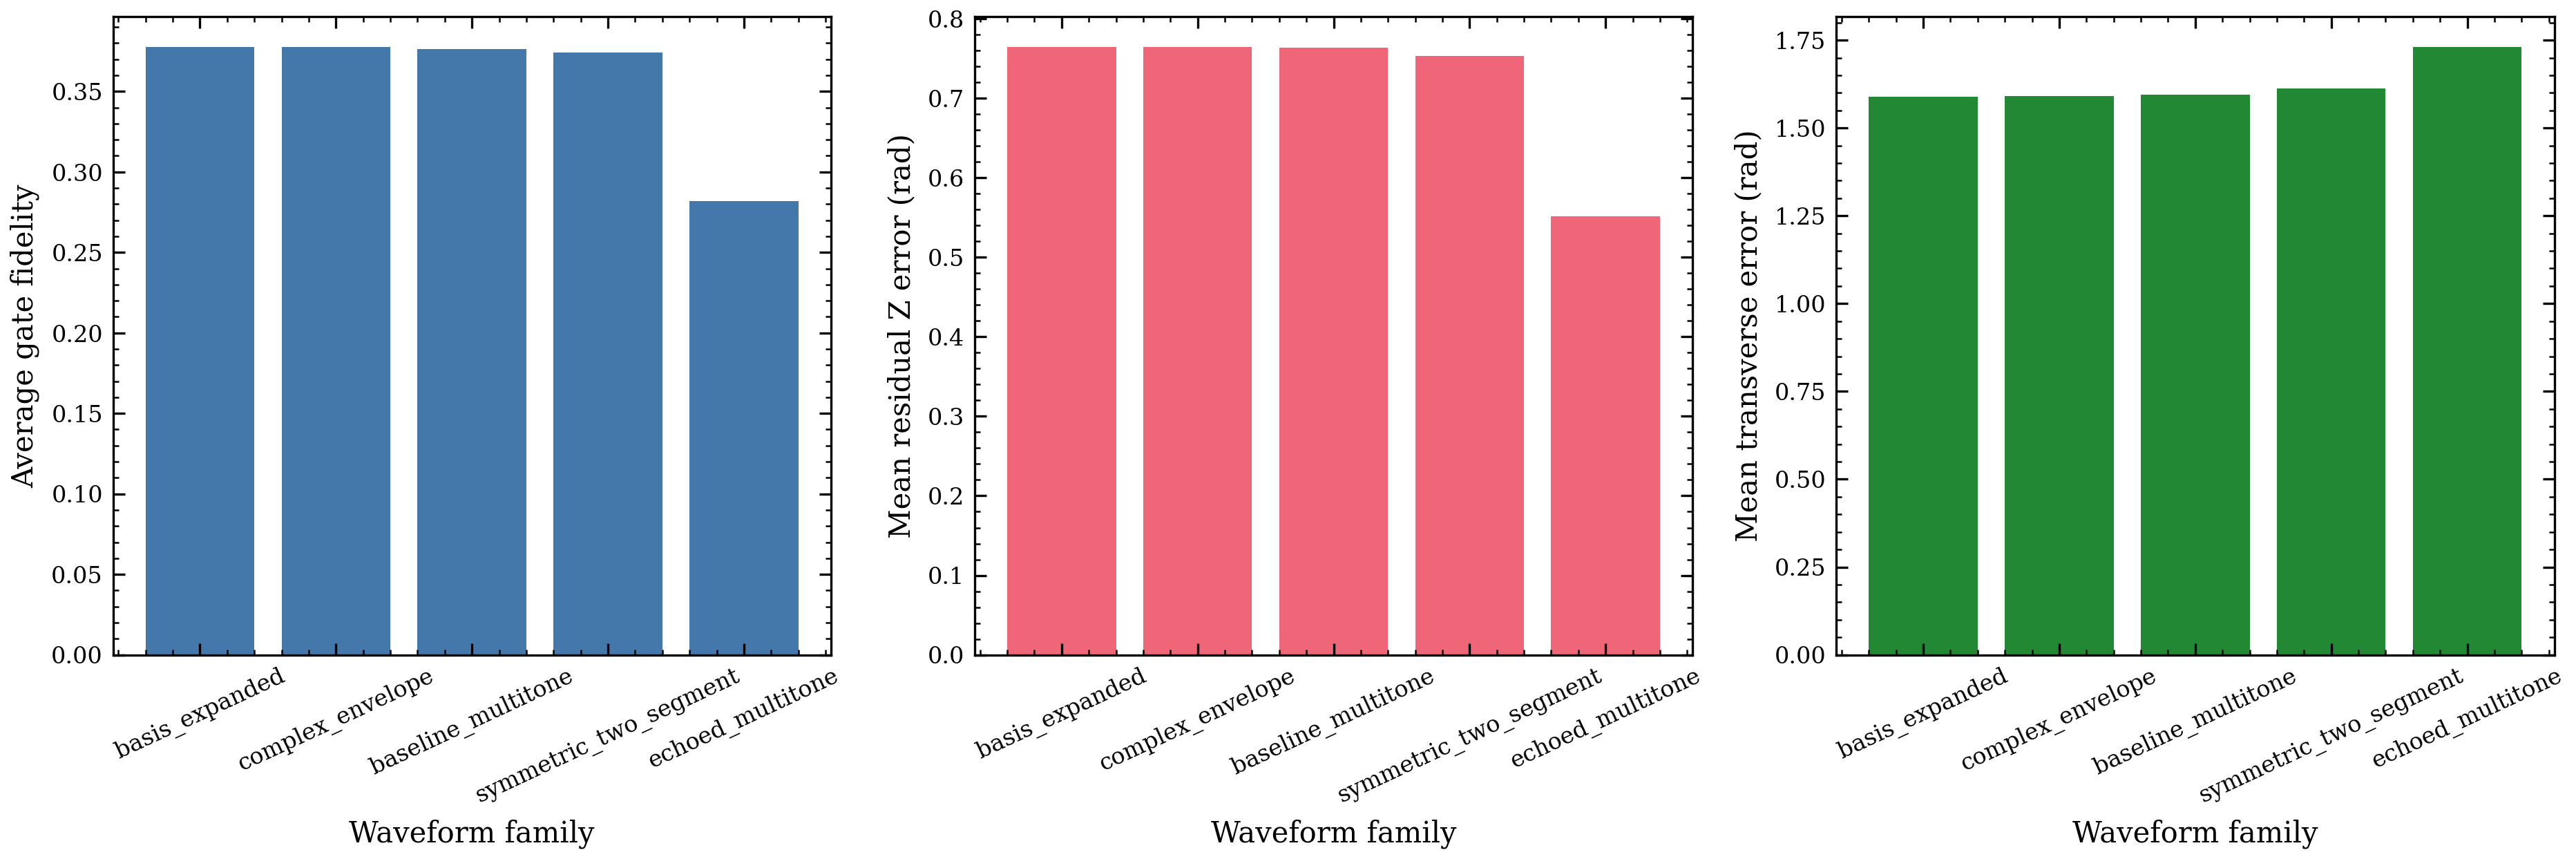

### case_family_fidelity_heatmap.png

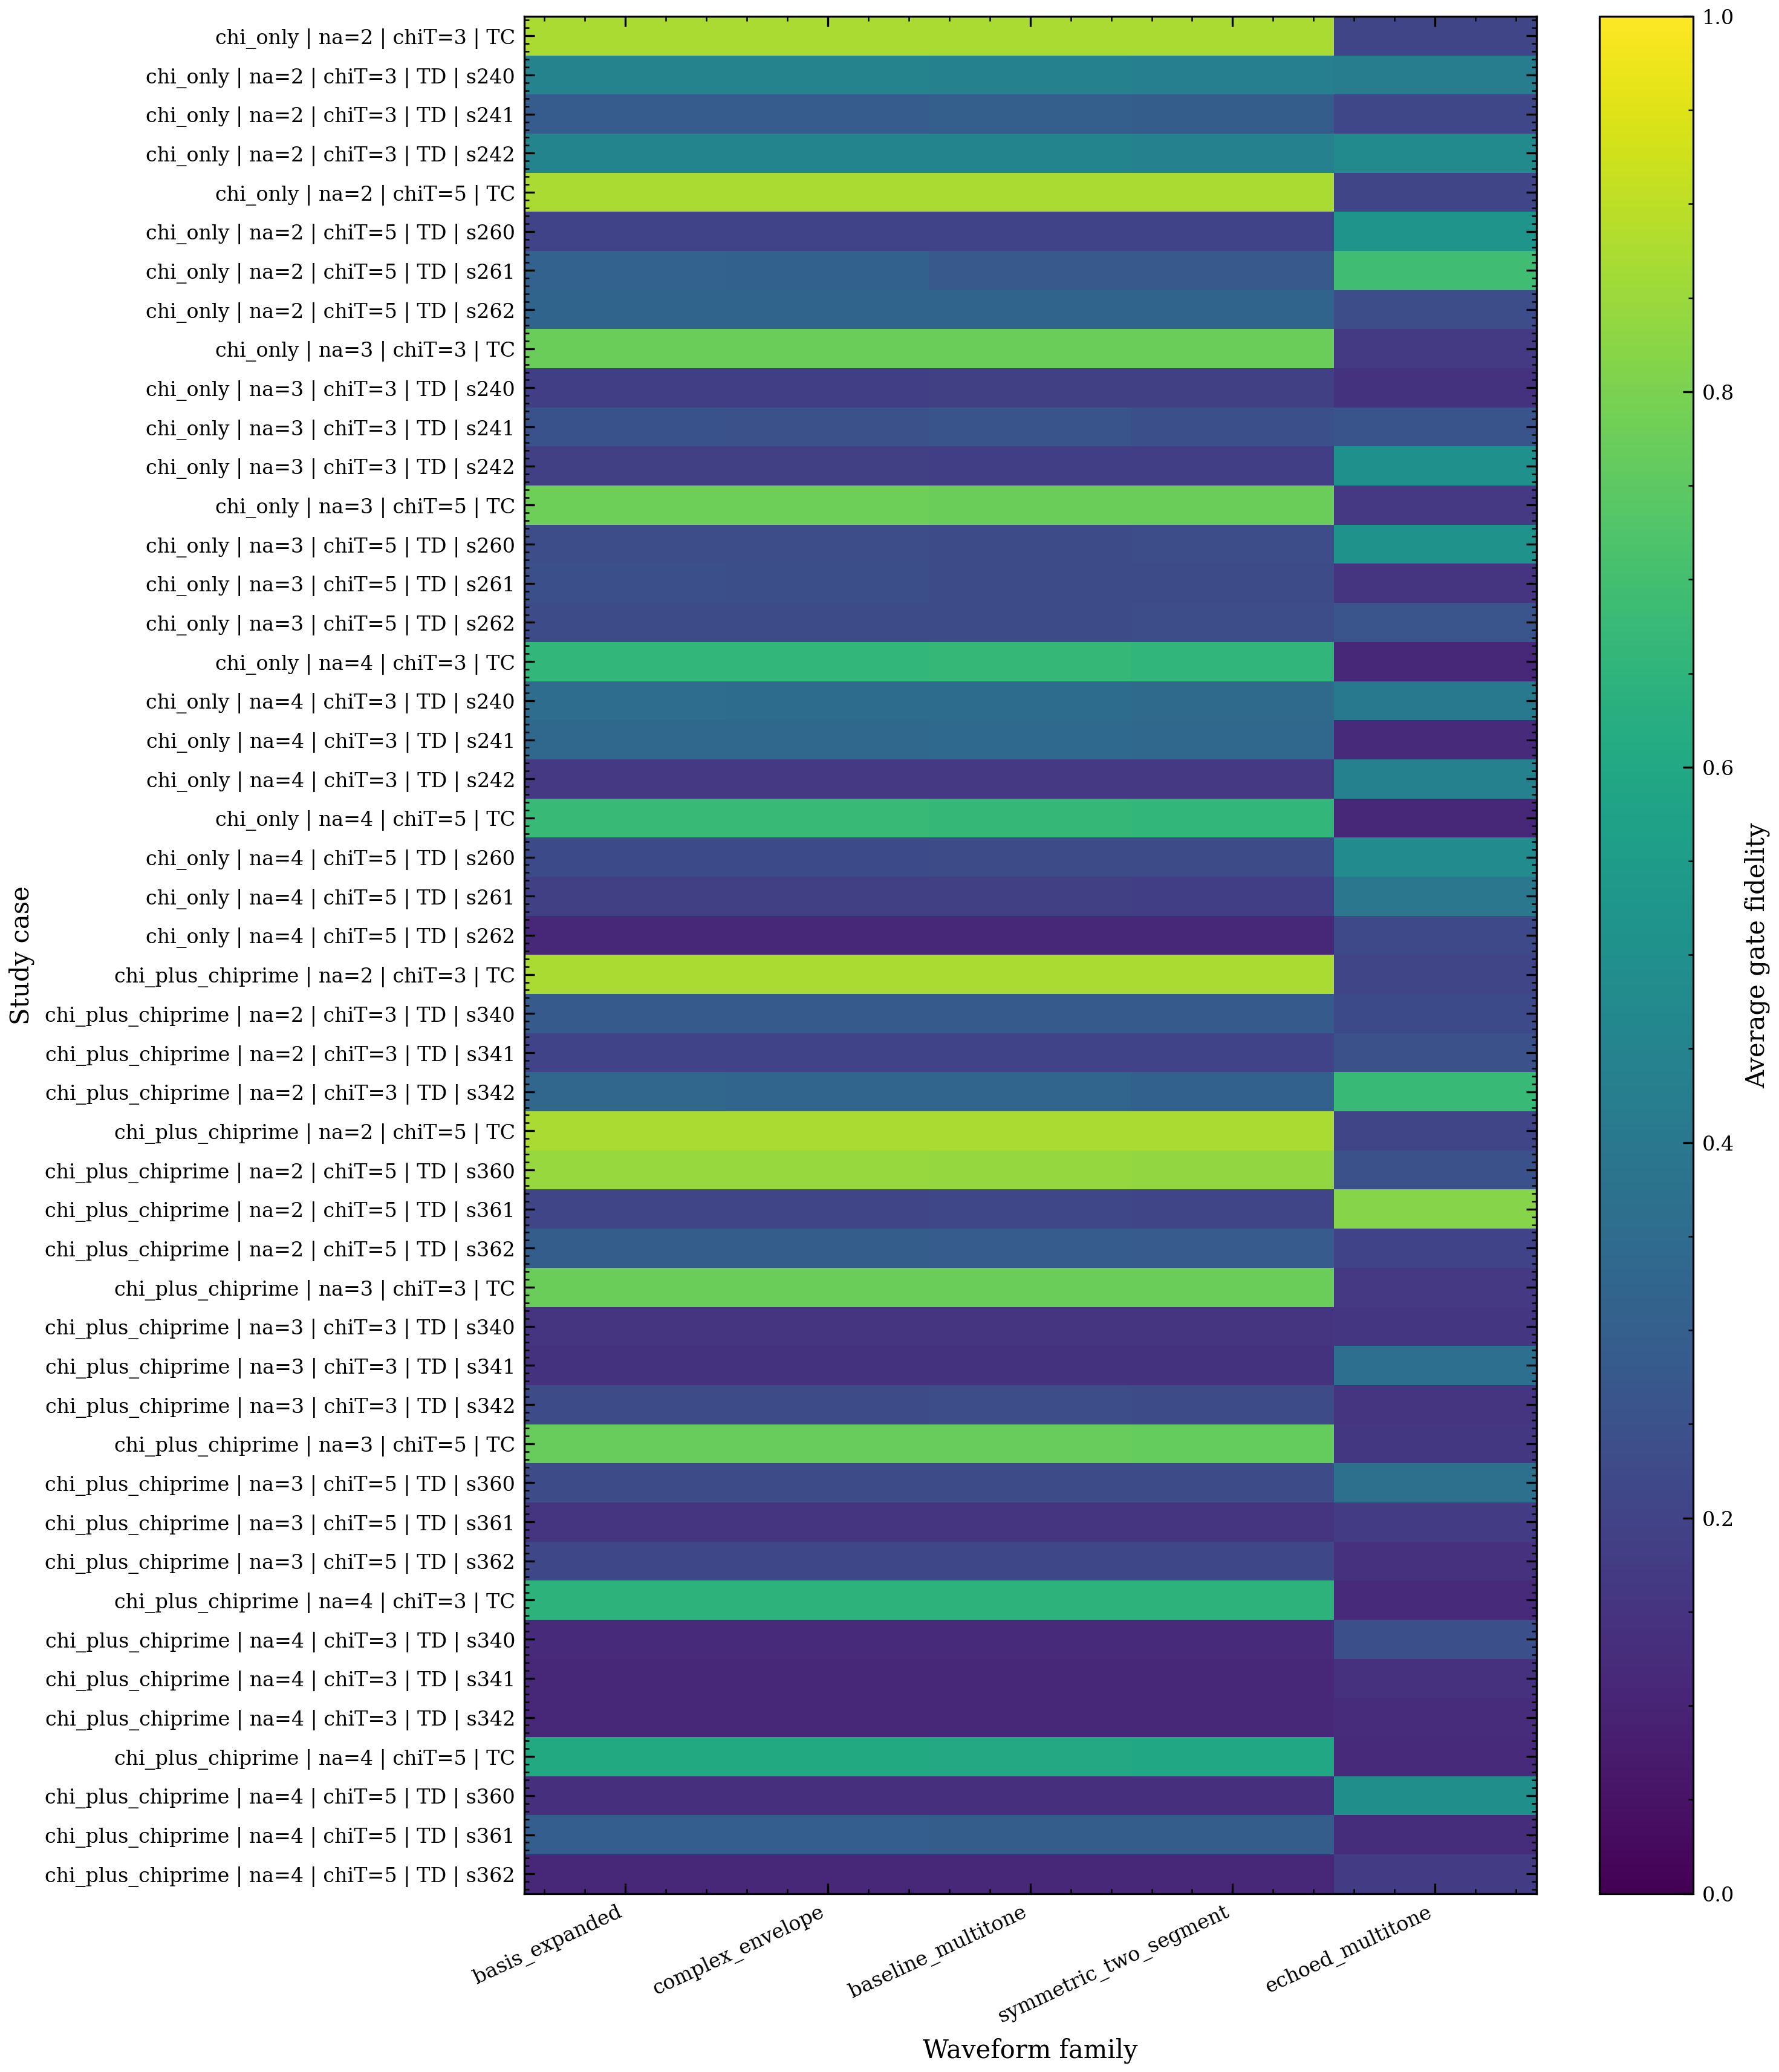

### fidelity_tradeoff_planes.png

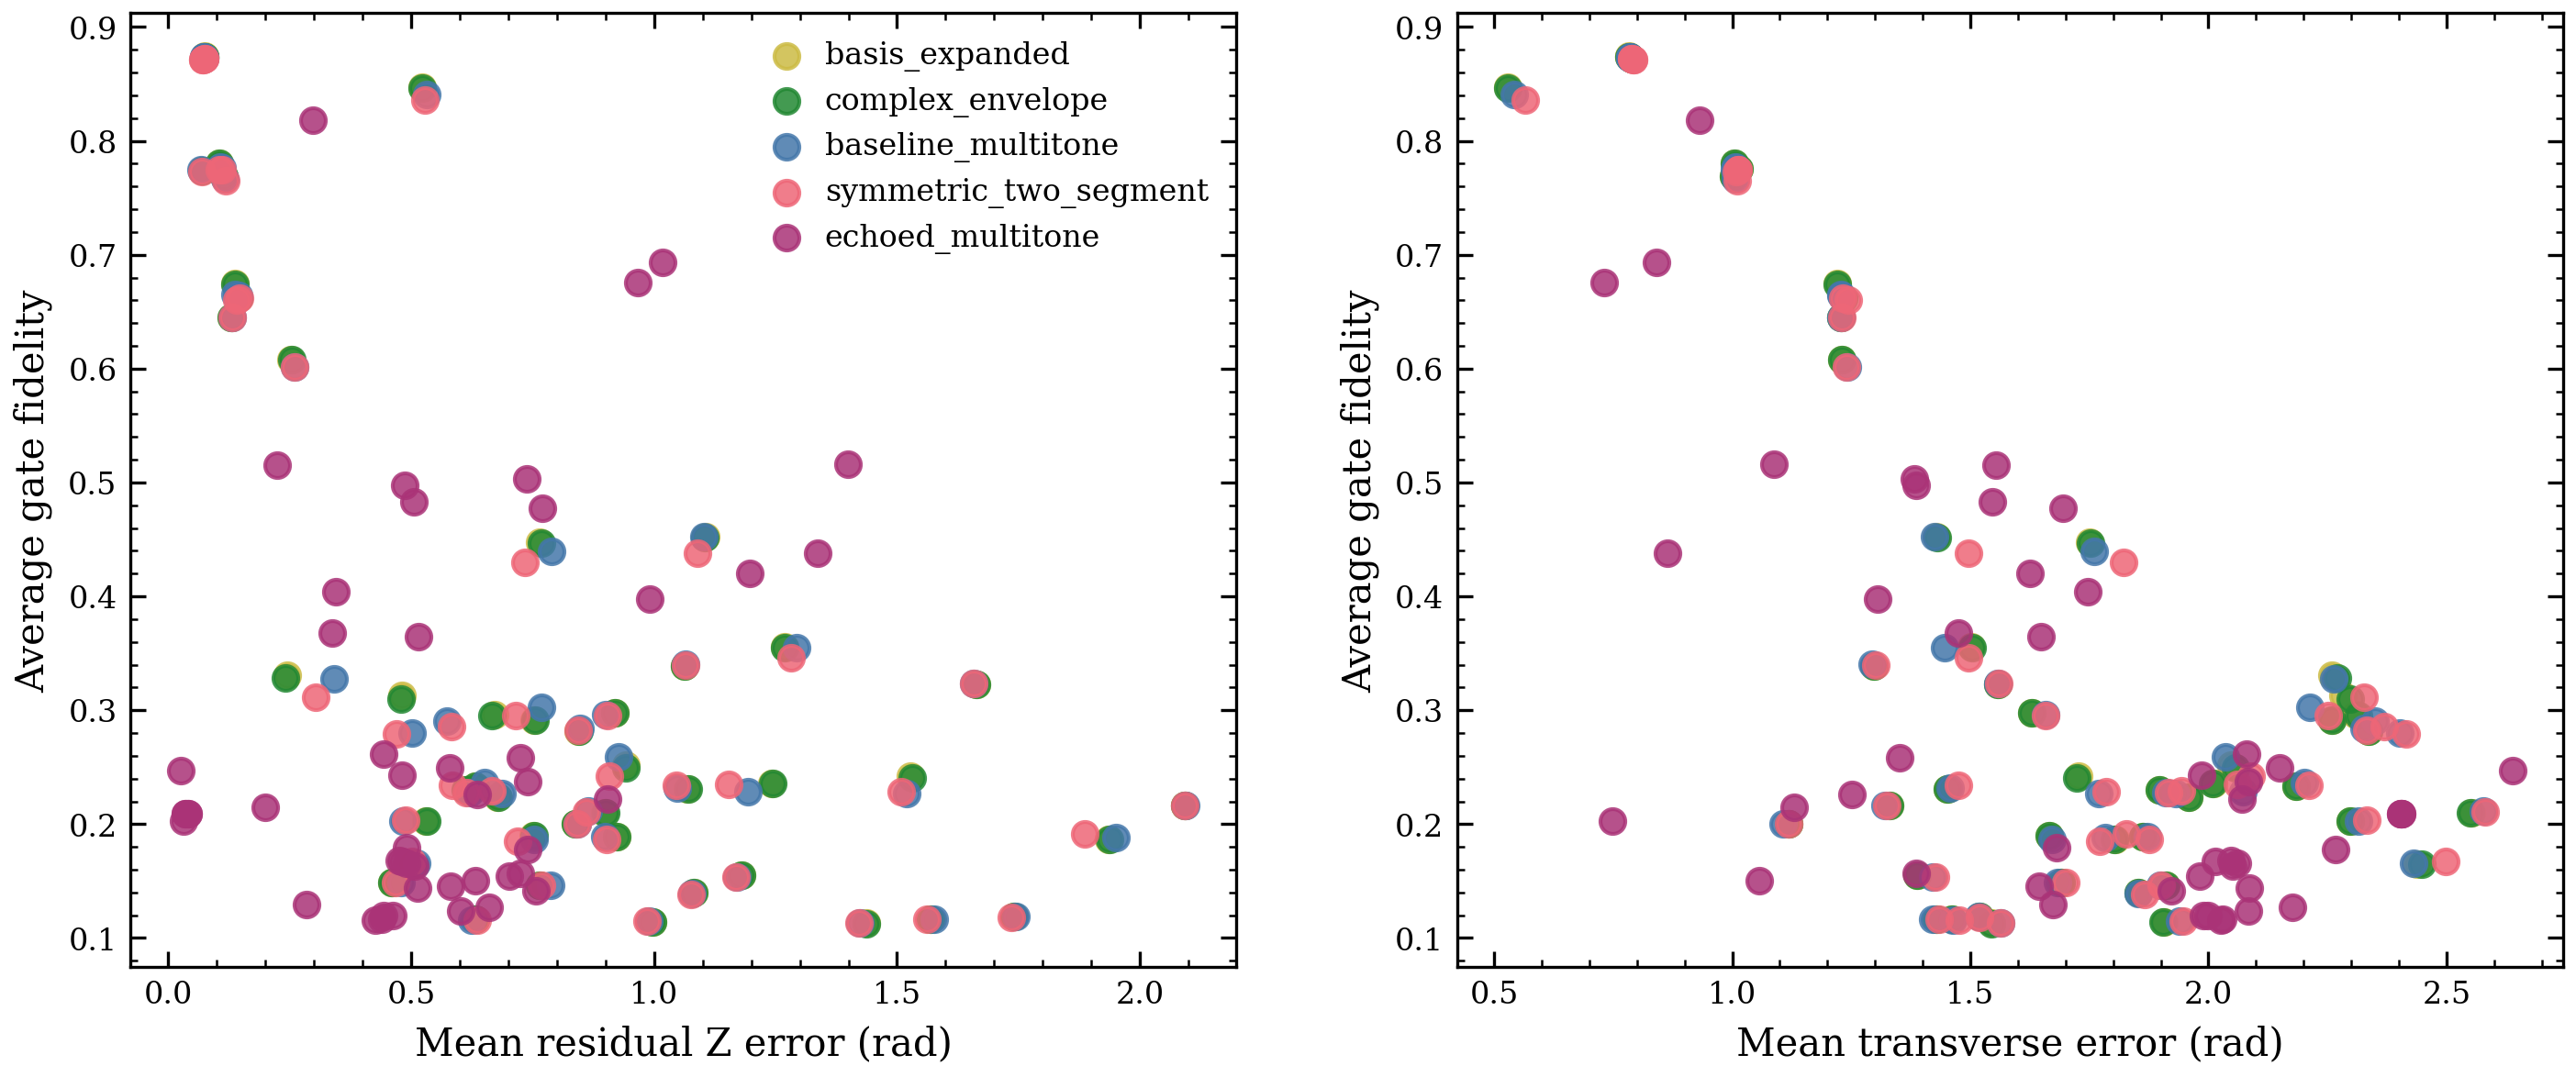

### residual_z_vs_transverse.png

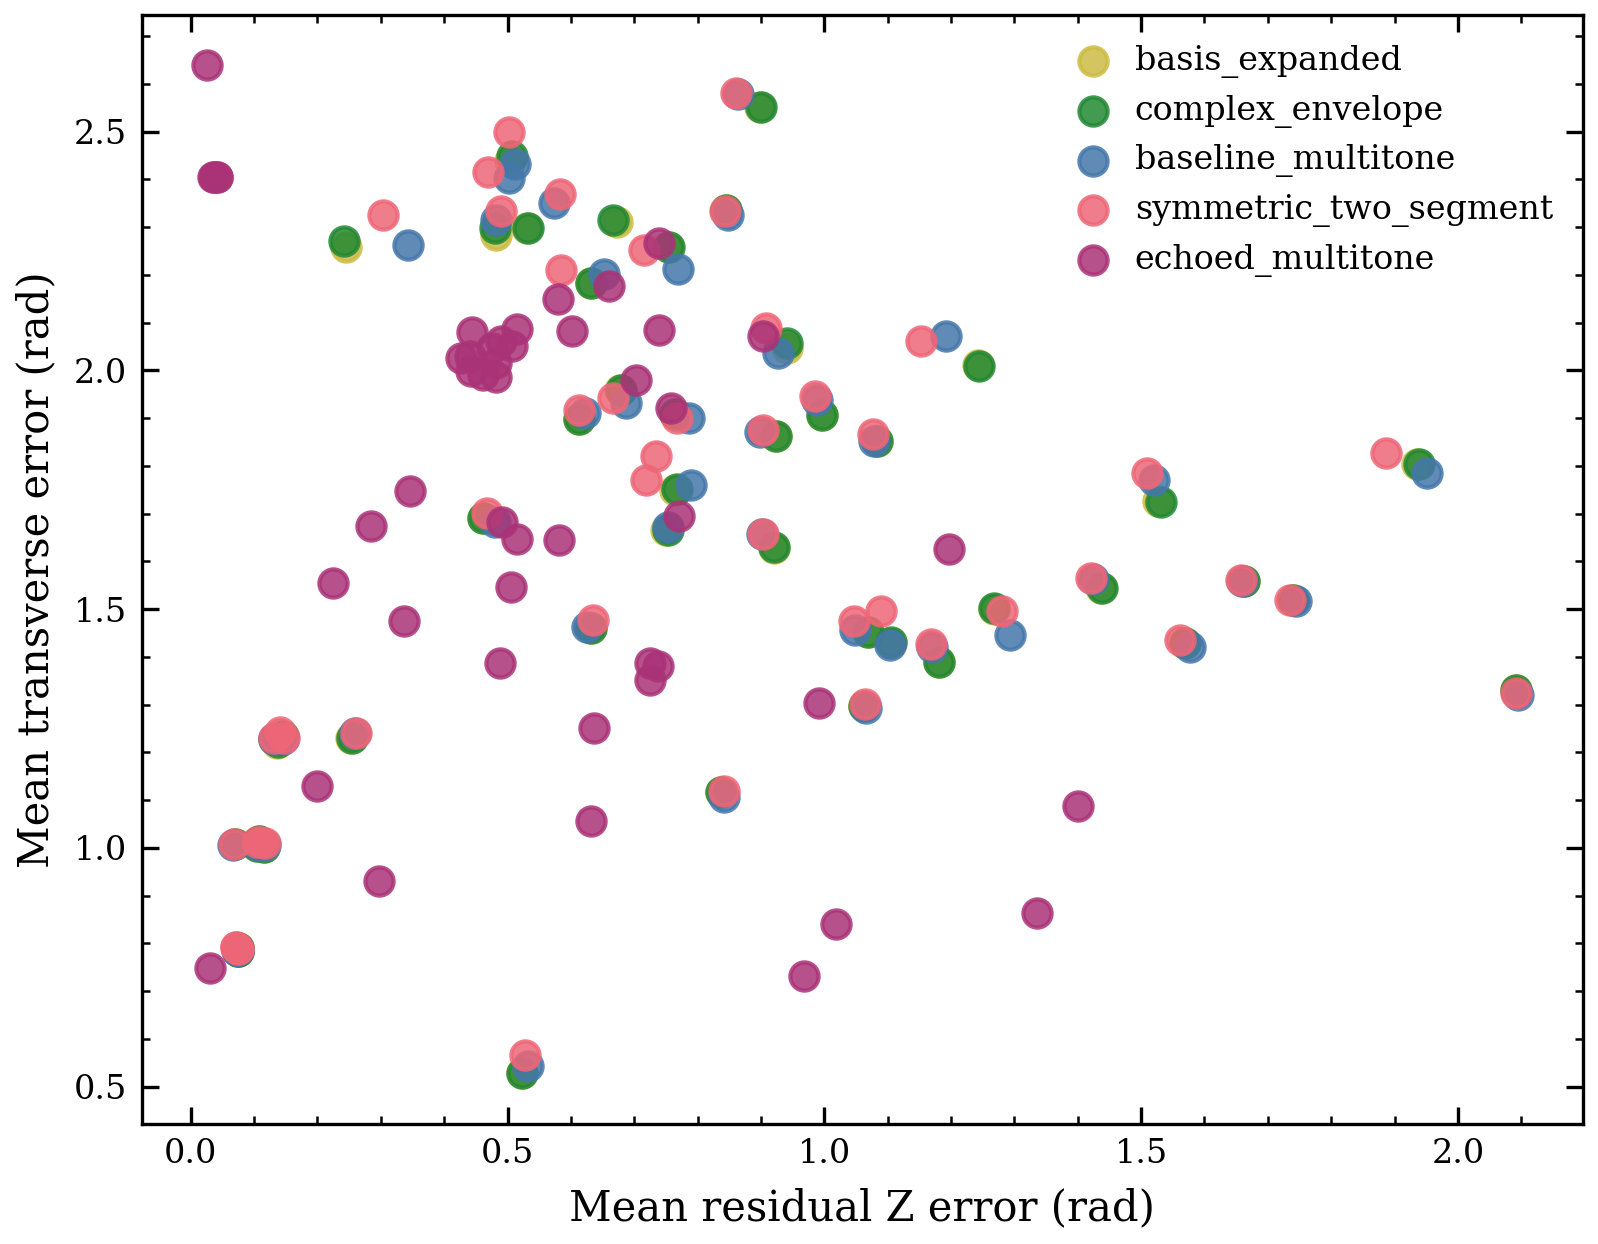

### representative_waveform_spectra.png

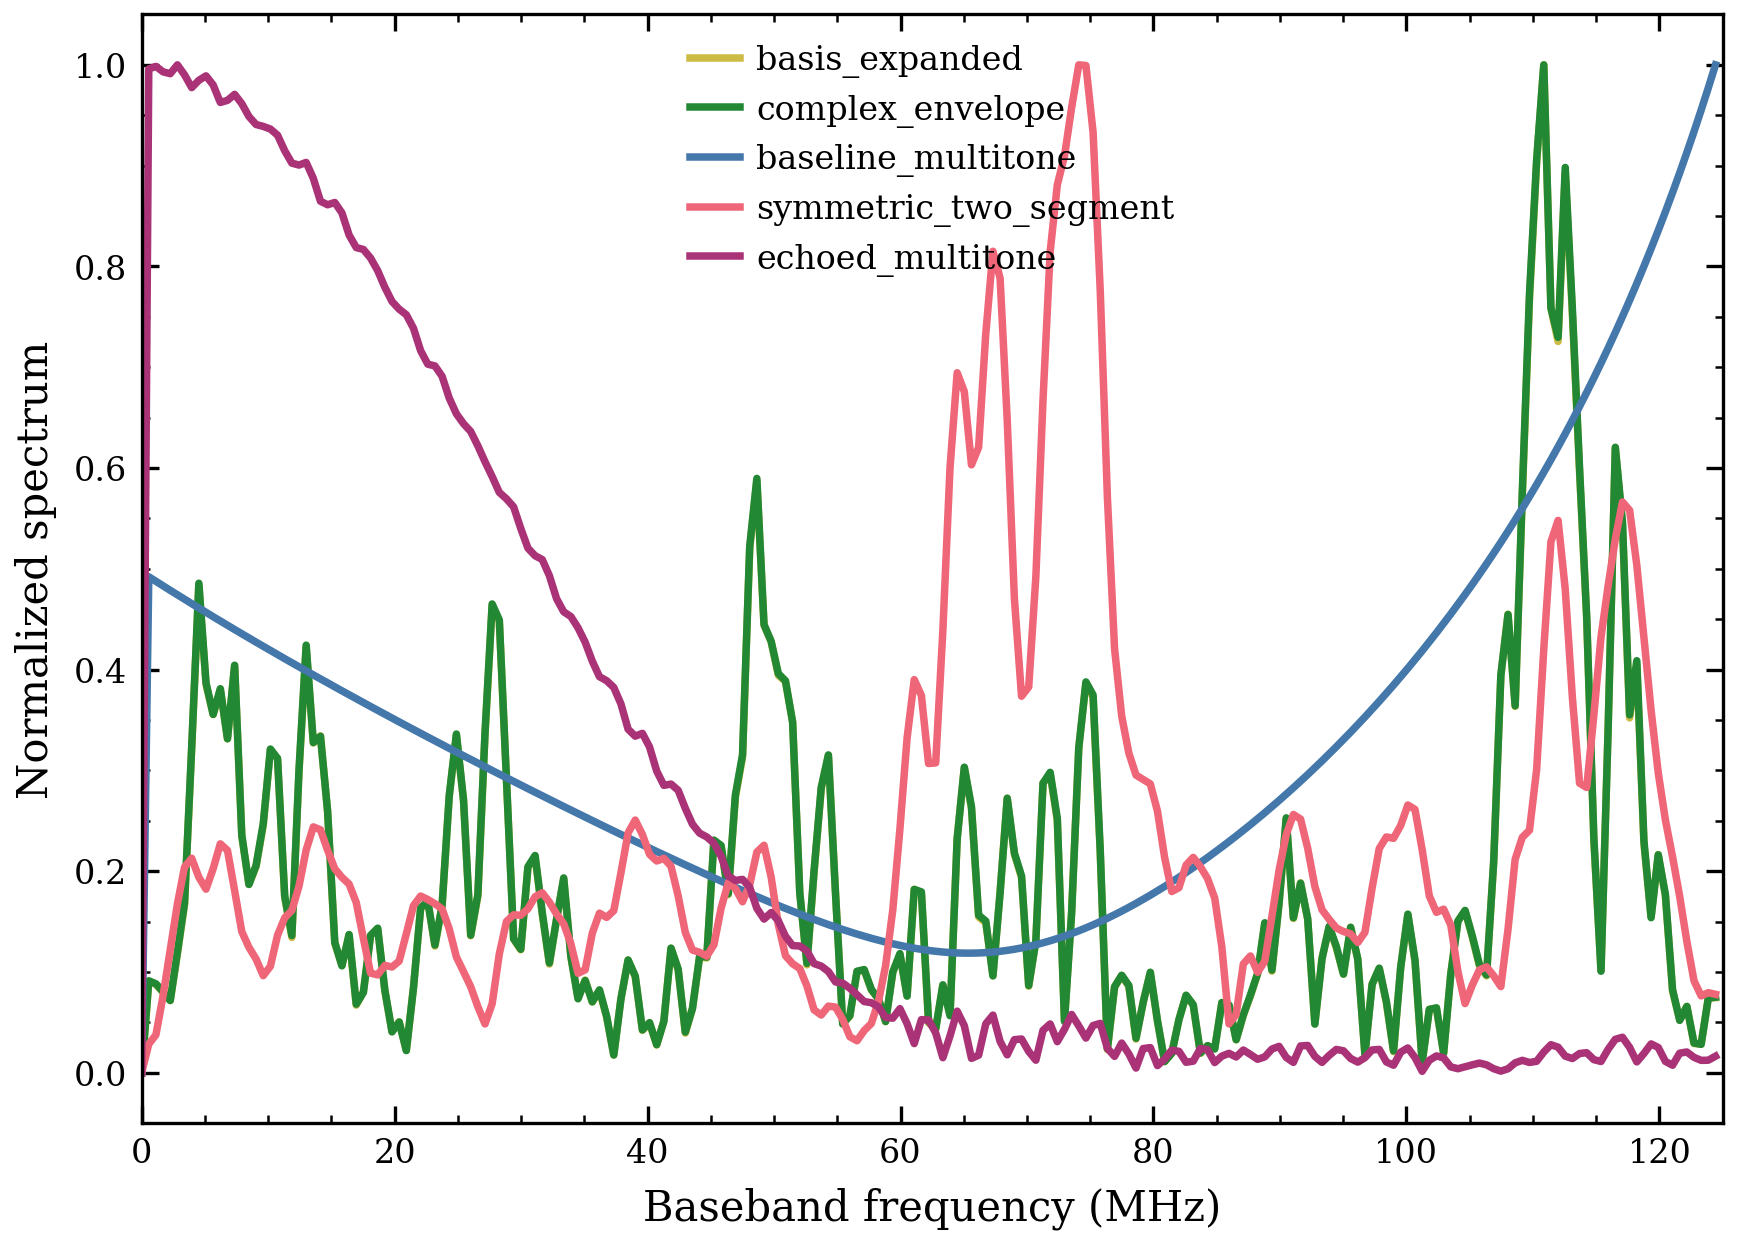

In [11]:
if show_figures:
    for figure_name in figure_names:
        figure_path = figures_dir / figure_name
        if figure_path.exists():
            display(Markdown(f"### {figure_name}"))
            display(Image(filename=str(figure_path)))
        else:
            print(f"Missing figure: {figure_path}")

## 5. Per-Case Comparison

This section lets you inspect the saved table rows for one case or one waveform family. It is useful for checking whether a richer family improved fidelity, reduced residual Z, reduced transverse coherent error, or traded these objectives against one another.

In [12]:
if filtered_df.empty:
    print("No rows matched the current filters.")
else:
    display(
        filtered_df[
            [
                "case_id",
                "waveform_family",
                "average_gate_fidelity",
                "mean_residual_z_error_rad",
                "mean_transverse_error_rad",
                "state_validation_plus_fidelity",
            ]
        ].sort_values(["case_id", "average_gate_fidelity"], ascending=[True, False])
    )

,case_id,waveform_family,average_gate_fidelity,mean_residual_z_error_rad,mean_transverse_error_rad,state_validation_plus_fidelity
0,chi_only_na2_chiT3p0_targetC,baseline_multitone,0.873359,0.073485,0.785581,0.894730
4,chi_only_na2_chiT3p0_targetC,basis_expanded,0.872256,0.073966,0.789533,0.893607
3,chi_only_na2_chiT3p0_targetC,complex_envelope,0.872255,0.073969,0.789531,0.893607
1,chi_only_na2_chiT3p0_targetC,symmetric_two_segment,0.871678,0.071663,0.791987,0.893194
2,chi_only_na2_chiT3p0_targetC,echoed_multitone,0.209487,0.035573,2.404461,0.014542
...,...,...,...,...,...,...
237,chi_plus_chiprime_na4_chiT5p0_targetD_seed94362,echoed_multitone,0.179564,0.491509,1.682038,0.034872
236,chi_plus_chiprime_na4_chiT5p0_targetD_seed94362,symmetric_two_segment,0.114815,0.984696,1.946633,0.003626
235,chi_plus_chiprime_na4_chiT5p0_targetD_seed94362,baseline_multitone,0.114754,0.988343,1.938828,0.003599
239,chi_plus_chiprime_na4_chiT5p0_targetD_seed94362,basis_expanded,0.113710,0.996583,1.905908,0.005392


## 6. Re-Run With Current Parameters

The default notebook path is artifact-first. The next cell is intentionally commented out so the expensive expanded-study runner is not triggered unless you explicitly want to reproduce one case with the current Python environment.

In [ ]:
# --- Re-run with current parameters ---
# import subprocess
# import shlex
# command = [
#     python_executable,
#     str(scripts_dir / "run_study.py"),
#     "--case",
#     rerun_case_id,
# ]
# print("Running:", shlex.join(command))
# completed = subprocess.run(command, cwd=str(study_dir), check=True, capture_output=True, text=True)
# print(completed.stdout)
# if completed.stderr:
#     print(completed.stderr)

## 7. Summary

The current notebook reproduces the saved expanded sweep across `N_active = 2, 3, 4`. The main result is split by target class: the basis-expanded and complex-envelope families remain the best single-segment refinements on the smooth structured family, while the explicit echoed family wins most of the hard random cases by lowering both residual-Z and transverse coherent error, even though it fails badly on the structured targets.

| Parameter | Default value | Effect on notebook output |
|---|---:|---|
| `case_id_filter` | empty string | Restricts tables to one saved case |
| `waveform_family_filter` | empty string | Restricts tables to one waveform family |
| `figure_names` | five expanded-study figure filenames | Controls which saved figures are displayed |
| `rerun_case_id` | `chi_plus_chiprime_na4_chiT5p0_targetD_seed94360` | Selects the case used by the commented rerun cell |
| `show_tables` | `True` | Enables dataframe displays |
| `show_figures` | `True` | Enables PNG figure display |
| `python_executable` | system Python 3.12 path | Used only by the commented rerun cell |